# Week 4: Machine Learning Model Development and Evaluation

## Machine Learning Model Development Using Logistic Regression

**Dataset:** Breast Cancer Wisconsin Dataset  
**Algorithm:** Logistic Regression  
**Problem Type:** Binary Classification

## 1. Introduction

Machine Learning is a branch of Artificial Intelligence that enables computers to learn patterns from data and make predictions without being explicitly programmed for every decision.

In this project, a machine learning classification model is developed using Python and Scikit-learn. The Breast Cancer Wisconsin dataset is used, and Logistic Regression is selected as the classification algorithm.

The complete machine learning workflow includes data exploration, data cleaning, preprocessing, model training, prediction, evaluation, visualization, and analysis of model performance.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [42]:
data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 2. Project Objective

The main objective of this project is to develop and evaluate a basic machine learning classification model.

The project aims to:

- Explore and understand the dataset.
- Check the dataset for missing and duplicate values.
- Prepare the data for machine learning.
- Split the data into training and testing sets.
- Standardize the numerical features.
- Develop a Logistic Regression model.
- Train the model using the training data.
- Generate predictions for the test data.
- Evaluate the model using appropriate classification metrics.
- Visualize model performance using a confusion matrix and ROC curve.
- Analyze possible errors, limitations, and improvements.

In [43]:
print("Dataset Shape:")
print(X.shape)

print("\nFirst 5 Rows:")
display(X.head())

print("\nTarget Classes:")
print(data.target_names)

print("\nTarget Distribution:")
print(y.value_counts())

Dataset Shape:
(569, 30)

First 5 Rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target Classes:
['malignant' 'benign']

Target Distribution:
target
1    357
0    212
Name: count, dtype: int64


In [44]:
print("Dataset Information:")
X.info()

print("\nStatistical Summary:")
display(X.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoot

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 3. Data Preparation and Cleaning

Data preparation is an important step in machine learning because the quality and structure of the input data can affect model performance.

The dataset is inspected to understand its structure and statistical characteristics. Missing values and duplicate records are checked before model training.

The features are separated from the target variable, and the dataset is divided into training and testing sets. The numerical features are then standardized using StandardScaler.

In [45]:
missing_values = X.isnull().sum()

print("Missing Values:")
print(missing_values)

print("\nTotal Missing Values:")
print(missing_values.sum())

Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

Total Missing Values:
0


In [46]:
duplicate_count = X.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [47]:
print("Target Class Names:")
print(data.target_names)

print("\nTarget Values:")
print(y.value_counts())

Target Class Names:
['malignant' 'benign']

Target Values:
target
1    357
0    212
Name: count, dtype: int64


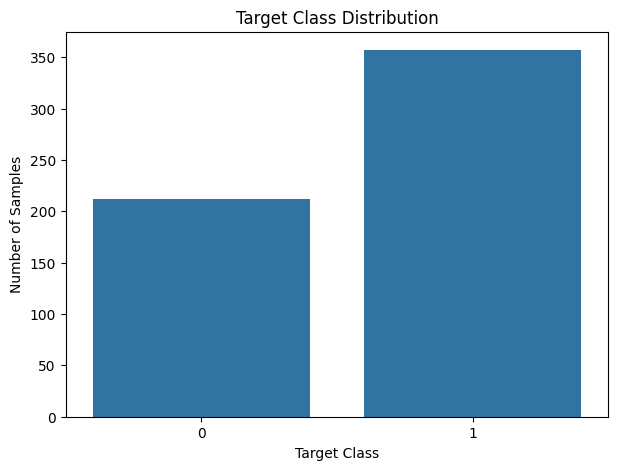

In [48]:
plt.figure(figsize=(7, 5))

sns.countplot(x=y)

plt.title("Target Class Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Samples")

plt.show()

### 3.1 Train-Test Split

The dataset is divided into two parts:

- 80% of the data is used for training the model.
- 20% of the data is used for testing the model.

The training data is used by the model to learn patterns, while the testing data is used to evaluate how well the trained model performs on previously unseen observations.

A random state of 42 is used to make the results reproducible, and stratification is applied to preserve the class distribution.

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


### 3.2 Feature Standardization

The numerical features are standardized using StandardScaler.

Standardization transforms the features so that they are placed on a comparable scale. This is useful for Logistic Regression because the original features may have different numerical ranges.

The scaler is fitted only on the training data and then applied to both the training and testing data. This prevents information from the test dataset from being used during training.

In [50]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed successfully!")

Feature standardization completed successfully!


In [51]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


## Why Logistic Regression?

Logistic Regression was selected because this project is a binary classification problem. The algorithm is simple, efficient, interpretable, and widely used for classification tasks. It provides a suitable baseline model for evaluating the performance of a machine learning classification system.

## 4. Model Training

The Logistic Regression model is trained using the standardized training dataset.

During training, the model learns the relationship between the input features and the target classes. After training, the model can be used to predict the class of new observations.

In [52]:
model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


## 5. Model Prediction

After training, the Logistic Regression model is used to make predictions on the test dataset.

Two types of outputs are generated:

- Predicted class labels are used to evaluate classification performance.
- Predicted probabilities are used to calculate the ROC-AUC score and generate the ROC curve.

In [53]:
y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully!")

print("\nFirst 10 Predictions:")
print(y_pred[:10])

Predictions generated successfully!

First 10 Predictions:
[0 1 0 1 0 1 1 0 0 0]


## 6. Model Evaluation

The performance of the trained model is evaluated using several classification metrics.

### Accuracy

Accuracy represents the proportion of total predictions that were classified correctly.

### Precision

Precision measures how many of the observations predicted as positive were actually positive.

### Recall

Recall measures how many of the actual positive observations were correctly identified by the model.

### F1 Score

F1 Score combines precision and recall into a single metric and provides a balance between the two.

### ROC-AUC

ROC-AUC measures the model's ability to distinguish between the two classes across different classification thresholds.

In [54]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print("MODEL PERFORMANCE")
print("==========================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

MODEL PERFORMANCE
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861
ROC-AUC  : 0.9954


### 6.1 Classification Report

The classification report provides precision, recall, F1 Score, and support for each target class.

This provides a more detailed view of model performance than accuracy alone.

In [55]:
print("Classification Report")
print("==============================")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names
    )
)

Classification Report
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 7. Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions made by the classification model.

It contains four types of outcomes:

- True Positive: The model correctly predicts the positive class.
- True Negative: The model correctly predicts the negative class.
- False Positive: The model predicts the positive class when the actual class is negative.
- False Negative: The model predicts the negative class when the actual class is positive.

The confusion matrix helps identify the types of classification errors made by the model.

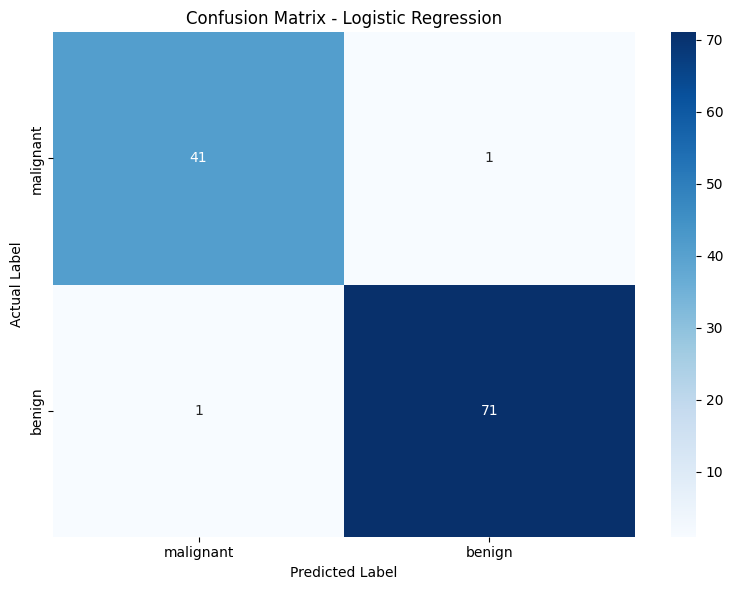

In [56]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. ROC Curve

The Receiver Operating Characteristic (ROC) curve shows the relationship between the True Positive Rate and False Positive Rate at different classification thresholds.

The Area Under the Curve (AUC) provides a summary of the model's ability to distinguish between the two classes.

A higher AUC generally indicates better classification discrimination.

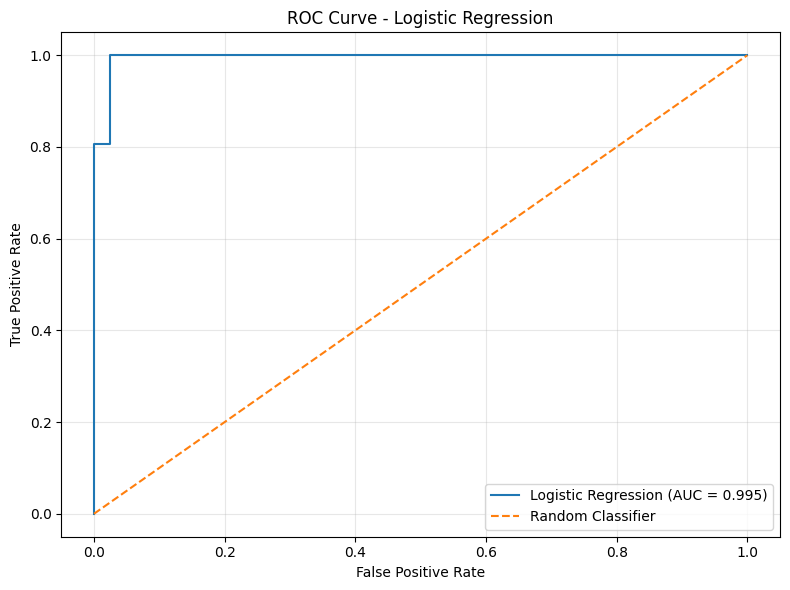

In [57]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Overfitting and Underfitting Analysis

Overfitting occurs when a model performs very well on the training data but performs considerably worse on unseen testing data.

Underfitting occurs when a model performs poorly on both training and testing data.

Training accuracy and testing accuracy are compared to identify whether there is a significant difference in performance between the training and testing datasets.

In [58]:
train_predictions = model.predict(X_train_scaled)

train_accuracy = accuracy_score(
    y_train,
    train_predictions
)

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Training Accuracy:", round(train_accuracy, 4))
print("Testing Accuracy :", round(test_accuracy, 4))

print(
    "Accuracy Difference:",
    round(train_accuracy - test_accuracy, 4)
)

Training Accuracy: 0.989
Testing Accuracy : 0.9825
Accuracy Difference: 0.0066


## 10. Sources of Error and Model Limitations

Several factors can affect the performance of the machine learning model.

Possible sources of error include:

- False positive predictions.
- False negative predictions.
- Limitations in the size and characteristics of the dataset.
- Differences between the available dataset and real-world data.
- Features that may not capture every factor relevant to classification.
- Limitations of Logistic Regression when relationships between variables are complex or non-linear.

Therefore, the model's results should be interpreted in the context of the dataset and the selected algorithm.

## 11. Possible Model Improvements

The model could potentially be improved through several approaches.

### More Data

A larger and more diverse dataset could help the model generalize better.

### Cross-Validation

Cross-validation could provide a more reliable estimate of model performance.

### Hyperparameter Tuning

Techniques such as GridSearchCV or RandomizedSearchCV could be used to identify better model parameters.

### Feature Selection

Selecting the most relevant features may reduce unnecessary information and improve model efficiency.

### Comparing Different Algorithms

Other classification algorithms such as Decision Trees, Random Forest, Support Vector Machines, and K-Nearest Neighbors could be evaluated and compared with Logistic Regression.

In [59]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results["Score"] = results["Score"].round(4)

display(results)

,Metric,Score
0,Accuracy,0.9825
1,Precision,0.9861
2,Recall,0.9861
3,F1 Score,0.9861
4,ROC-AUC,0.9954


## 12. Conclusion

This project demonstrated the complete machine learning model development and evaluation process using the Breast Cancer Wisconsin dataset and Logistic Regression.

The workflow included data exploration, data cleaning, preprocessing, train-test splitting, feature standardization, model training, prediction, and evaluation.

The model was evaluated using accuracy, precision, recall, F1 Score, ROC-AUC, a confusion matrix, and an ROC curve.

The analysis also considered possible overfitting, sources of error, model limitations, and potential improvements. This project demonstrates the importance of not only developing a machine learning model but also carefully evaluating and interpreting its performance.